# Car Price Model Exploration

A compact notebook for quickly comparing several regression models on the same data split.
The goal is model discovery, not final tuning or production deployment.


In [9]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


def find_project_root() -> Path:
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (path / "data" / "raw" / "cars.csv").exists():
            return path
    raise FileNotFoundError("Could not find data/raw/cars.csv")


PROJECT_ROOT = find_project_root()
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "cars.csv"
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
print(CSV_PATH)


C:\Users\tuomas.kuusisto_cens\projects\car-price-prediction\data\raw\cars.csv


## 1. Load and clean the data


In [10]:
numeric_features = [
    "mileage_km_raw", "vehicle_age", "nr_seats", "nr_doors", "power_hp",
    "gears", "cylinders", "cylinders_volume_cc", "weight_kg_numeric",
    "electric_range_km", "fuel_cons_comb_l100_km", "co2_emission_grper_km",
    "nr_prev_owners",
]

categorical_features = [
    "make", "model", "paint_type", "transmission", "drive_train",
    "fuel_category", "primary_fuel", "is_used", "is_new", "had_accident",
    "has_full_service_history", "is_rental", "envir_standard", "offer_type",
    "country_code", "seller_is_dealer", "seller_type",
]

raw_columns = [
    "id", "price", "registration_date", "weight_kg",
    *[column for column in numeric_features if column not in {"vehicle_age", "weight_kg_numeric"}],
    *categorical_features,
]

df = pd.read_csv(CSV_PATH, usecols=raw_columns, low_memory=False)
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["vehicle_age"] = pd.Timestamp.today().year - df["registration_date"].dt.year
df.loc[~df["vehicle_age"].between(0, 80), "vehicle_age"] = np.nan
df["weight_kg_numeric"] = pd.to_numeric(
    df["weight_kg"].astype("string").str.extract(r"([\d,.]+)", expand=False)
    .str.replace(",", "", regex=False),
    errors="coerce",
)

# Keep a practical baseline price range and require a country for stratification.
df = df.loc[
    df["price"].between(1_000, 1_000_000)
    & df["country_code"].notna()
].drop_duplicates("id")

features = numeric_features + categorical_features
X = df[features]
y = df["price"].astype(float)

print(f"Rows: {len(df):,}")
print(f"Features: {len(features)}")
print(f"Median price: €{y.median():,.0f}")


Rows: 118,045
Features: 30
Median price: €39,990


## 2. Split and preprocess once


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=X["country_code"],
)

preprocessor = ColumnTransformer(
    [
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            min_frequency=20,
                            max_categories=200,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_ready = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=numeric_features + categorical_features,
    index=X_train.index,
)
X_test_ready = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=numeric_features + categorical_features,
    index=X_test.index,
)

for column in categorical_features:
    X_train_ready[column] = X_train_ready[column].astype(int)
    X_test_ready[column] = X_test_ready[column].astype(int)

y_train_log = np.log1p(y_train)
germany_test = X_test["country_code"].eq("DE").to_numpy()

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")


Train rows: 94,436
Test rows: 23,609


## 3. Define candidate models


In [12]:
models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Random Forest": RandomForestRegressor(
        n_estimators=180, min_samples_leaf=2, max_features=0.8,
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=180, min_samples_leaf=2, max_features=0.9,
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.08, max_iter=300, max_leaf_nodes=31,
        min_samples_leaf=30, l2_regularization=1.0,
        categorical_features=categorical_features,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=450, learning_rate=0.05, max_depth=8,
        subsample=0.85, colsample_bytree=0.85,
        objective="reg:squarederror", n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=450, learning_rate=0.05, num_leaves=63,
        subsample=0.85, colsample_bytree=0.85,
        verbosity=-1, n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=450, learning_rate=0.07, depth=8,
        loss_function="RMSE", cat_features=categorical_features,
        verbose=100, random_seed=RANDOM_STATE,
    ),
}

list(models)


['Median baseline',
 'Random Forest',
 'Extra Trees',
 'HistGradientBoosting',
 'XGBoost',
 'LightGBM',
 'CatBoost']

## 4. Train and compare


In [13]:
results = []
predictions = {}

for number, (name, model) in enumerate(models.items(), start=1):
    print(f"\n[{number}/{len(models)}] Training {name}...", flush=True)
    started = perf_counter()
    model.fit(X_train_ready, y_train_log)
    seconds = perf_counter() - started

    predicted_price = np.clip(np.expm1(model.predict(X_test_ready)), 1_000, 1_000_000)
    predictions[name] = predicted_price

    results.append(
        {
            "model": name,
            "MAE": mean_absolute_error(y_test, predicted_price),
            "Germany MAE": mean_absolute_error(y_test.to_numpy()[germany_test], predicted_price[germany_test]),
            "RMSE": np.sqrt(mean_squared_error(y_test, predicted_price)),
            "R2": r2_score(y_test, predicted_price),
            "within 20%": np.mean(np.abs(predicted_price - y_test.to_numpy()) / y_test.to_numpy() <= 0.20),
            "seconds": seconds,
        }
    )
    print(f"Finished {name} in {seconds:.1f}s | MAE €{results[-1]['MAE']:,.0f}", flush=True)

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_df.style.format(
    {
        "MAE": "€{:,.0f}",
        "Germany MAE": "€{:,.0f}",
        "RMSE": "€{:,.0f}",
        "R2": "{:.3f}",
        "within 20%": "{:.1%}",
        "seconds": "{:.1f}",
    }
)



[1/7] Training Median baseline...


Finished Median baseline in 0.0s | MAE €32,947

[2/7] Training Random Forest...
Finished Random Forest in 6.1s | MAE €4,974

[3/7] Training Extra Trees...
Finished Extra Trees in 5.7s | MAE €4,919

[4/7] Training HistGradientBoosting...
Finished HistGradientBoosting in 2.0s | MAE €5,432

[5/7] Training XGBoost...
Finished XGBoost in 1.7s | MAE €5,143

[6/7] Training LightGBM...
Finished LightGBM in 1.9s | MAE €5,443

[7/7] Training CatBoost...
0:	learn: 0.8383997	total: 72.3ms	remaining: 32.5s
100:	learn: 0.1899321	total: 7.82s	remaining: 27s
200:	learn: 0.1676513	total: 15.8s	remaining: 19.5s
300:	learn: 0.1564010	total: 25.3s	remaining: 12.5s
400:	learn: 0.1495726	total: 36.7s	remaining: 4.48s
449:	learn: 0.1468309	total: 42.4s	remaining: 0us
Finished CatBoost in 43.0s | MAE €5,807


,model,MAE,Germany MAE,RMSE,R2,within 20%,seconds
0,Extra Trees,"€4,919","€4,891","€16,764",0.900,89.0%,5.7
1,Random Forest,"€4,974","€4,920","€16,548",0.903,88.9%,6.1
2,XGBoost,"€5,143","€5,219","€15,996",0.909,89.7%,1.7
3,HistGradientBoosting,"€5,432","€5,493","€16,886",0.899,88.9%,2.0
4,LightGBM,"€5,443","€5,466","€16,449",0.904,88.7%,1.9
5,CatBoost,"€5,807","€5,918","€17,053",0.897,87.2%,43.0
6,Median baseline,"€32,947","€32,213","€55,492",-0.095,18.5%,0.0


## 5. Try a simple ensemble


In [14]:
top_models = results_df.head(3)["model"].tolist()
ensemble_prediction = np.mean([predictions[name] for name in top_models], axis=0)

ensemble_row = pd.DataFrame(
    [
        {
            "model": f"Top-3 ensemble ({', '.join(top_models)})",
            "MAE": mean_absolute_error(y_test, ensemble_prediction),
            "Germany MAE": mean_absolute_error(y_test.to_numpy()[germany_test], ensemble_prediction[germany_test]),
            "RMSE": np.sqrt(mean_squared_error(y_test, ensemble_prediction)),
            "R2": r2_score(y_test, ensemble_prediction),
            "within 20%": np.mean(np.abs(ensemble_prediction - y_test.to_numpy()) / y_test.to_numpy() <= 0.20),
            "seconds": 0.0,
        }
    ]
)

predictions[ensemble_row.loc[0, "model"]] = ensemble_prediction
results_df = pd.concat([results_df, ensemble_row], ignore_index=True).sort_values("MAE").reset_index(drop=True)

results_df.style.format(
    {
        "MAE": "€{:,.0f}", "Germany MAE": "€{:,.0f}", "RMSE": "€{:,.0f}",
        "R2": "{:.3f}", "within 20%": "{:.1%}", "seconds": "{:.1f}",
    }
)


,model,MAE,Germany MAE,RMSE,R2,within 20%,seconds
0,"Top-3 ensemble (Extra Trees, Random Forest, XGBoost)","€4,803","€4,811","€16,112",0.908,90.2%,0.0
1,Extra Trees,"€4,919","€4,891","€16,764",0.900,89.0%,5.7
2,Random Forest,"€4,974","€4,920","€16,548",0.903,88.9%,6.1
3,XGBoost,"€5,143","€5,219","€15,996",0.909,89.7%,1.7
4,HistGradientBoosting,"€5,432","€5,493","€16,886",0.899,88.9%,2.0
5,LightGBM,"€5,443","€5,466","€16,449",0.904,88.7%,1.9
6,CatBoost,"€5,807","€5,918","€17,053",0.897,87.2%,43.0
7,Median baseline,"€32,947","€32,213","€55,492",-0.095,18.5%,0.0


## 6. Visual comparison


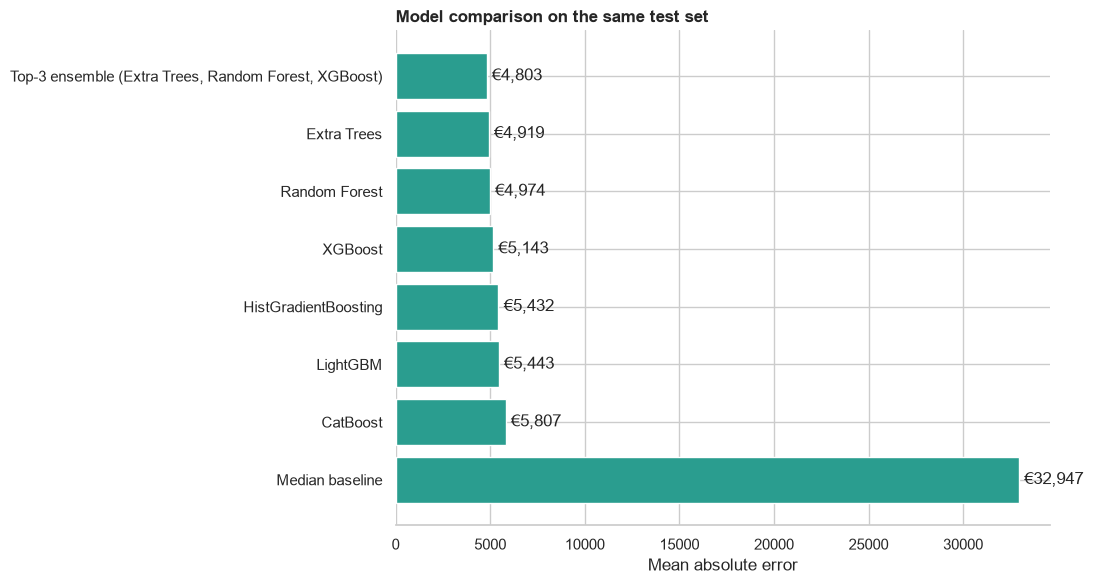

Best model: Top-3 ensemble (Extra Trees, Random Forest, XGBoost)
MAE: €4,803
Germany MAE: €4,811


In [15]:
plot_results = results_df.sort_values("MAE", ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(plot_results["model"], plot_results["MAE"], color="#2A9D8F")
ax.bar_label(bars, labels=[f"€{value:,.0f}" for value in plot_results["MAE"]], padding=4)
ax.set_title("Model comparison on the same test set", loc="left", fontweight="bold")
ax.set_xlabel("Mean absolute error")
ax.set_ylabel("")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

best_name = results_df.iloc[0]["model"]
best_prediction = predictions[best_name]
print(f"Best model: {best_name}")
print(f"MAE: €{results_df.iloc[0]['MAE']:,.0f}")
print(f"Germany MAE: €{results_df.iloc[0]['Germany MAE']:,.0f}")


## Next step

Choose the best one or two models, then optimize them with cross-validation. Keep the test
set untouched during optimization.


## 7. Light optimization of the three best models


In [16]:
# Light hyperparameter search for the three best individual models.
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV


search_spaces = {
    "Extra Trees": {
        "regressor__n_estimators": [140, 220, 320],
        "regressor__max_depth": [None, 20, 35],
        "regressor__min_samples_leaf": [1, 2, 4],
        "regressor__max_features": [0.6, 0.8, 1.0],
    },
    "Random Forest": {
        "regressor__n_estimators": [140, 220, 320],
        "regressor__max_depth": [None, 20, 35],
        "regressor__min_samples_leaf": [1, 2, 4],
        "regressor__max_features": [0.5, 0.7, 0.9],
    },
    "XGBoost": {
        "regressor__n_estimators": [300, 500, 700],
        "regressor__learning_rate": [0.03, 0.05, 0.08],
        "regressor__max_depth": [6, 8, 10],
        "regressor__min_child_weight": [1, 5, 10],
        "regressor__subsample": [0.75, 0.9, 1.0],
        "regressor__colsample_bytree": [0.75, 0.9, 1.0],
        "regressor__reg_lambda": [1.0, 5.0, 10.0],
    },
}

best_three = (
    results_df.loc[results_df["model"].isin(search_spaces)]
    .nsmallest(3, "MAE")["model"]
    .tolist()
)
print("Models selected for tuning:", best_three)

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_models = {}
tuned_predictions = {}
tuning_rows = []

for number, name in enumerate(best_three, start=1):
    print(f"\n[{number}/{len(best_three)}] Tuning {name}...", flush=True)
    base_model = clone(models[name])
    if "n_jobs" in base_model.get_params():
        base_model.set_params(n_jobs=1)

    estimator = TransformedTargetRegressor(
        regressor=base_model,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=search_spaces[name],
        n_iter=5,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=3,
        verbose=2,
        random_state=RANDOM_STATE,
        refit=True,
    )

    started = perf_counter()
    search.fit(X_train_ready, y_train)
    seconds = perf_counter() - started
    prediction = np.clip(search.predict(X_test_ready), 1_000, 1_000_000)

    tuned_models[name] = search.best_estimator_
    tuned_predictions[name] = prediction
    tuning_rows.append(
        {
            "model": name,
            "CV MAE": -search.best_score_,
            "test MAE": mean_absolute_error(y_test, prediction),
            "Germany MAE": mean_absolute_error(
                y_test.to_numpy()[germany_test], prediction[germany_test]
            ),
            "seconds": seconds,
            "best parameters": search.best_params_,
        }
    )
    print(
        f"Finished {name} in {seconds:.1f}s | "
        f"CV MAE €{-search.best_score_:,.0f} | "
        f"test MAE €{tuning_rows[-1]['test MAE']:,.0f}",
        flush=True,
    )

tuned_ensemble = np.mean(list(tuned_predictions.values()), axis=0)
tuning_rows.append(
    {
        "model": "Tuned top-3 ensemble",
        "CV MAE": np.nan,
        "test MAE": mean_absolute_error(y_test, tuned_ensemble),
        "Germany MAE": mean_absolute_error(
            y_test.to_numpy()[germany_test], tuned_ensemble[germany_test]
        ),
        "seconds": 0.0,
        "best parameters": {},
    }
)

tuning_results_df = pd.DataFrame(tuning_rows).sort_values("test MAE").reset_index(drop=True)
tuning_results_df.style.format(
    {
        "CV MAE": "€{:,.0f}",
        "test MAE": "€{:,.0f}",
        "Germany MAE": "€{:,.0f}",
        "seconds": "{:.1f}",
    },
    na_rep="—",
)


Models selected for tuning: ['Extra Trees', 'Random Forest', 'XGBoost']

[1/3] Tuning Extra Trees...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Finished Extra Trees in 235.5s | CV MAE €5,025 | test MAE €4,840

[2/3] Tuning Random Forest...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Finished Random Forest in 292.2s | CV MAE €5,117 | test MAE €4,875

[3/3] Tuning XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Finished XGBoost in 113.8s | CV MAE €4,964 | test MAE €4,869


,model,CV MAE,test MAE,Germany MAE,seconds,best parameters
0,Tuned top-3 ensemble,—,"€4,688","€4,677",0.0,{}
1,Extra Trees,"€5,025","€4,840","€4,829",235.5,"{'regressor__n_estimators': 140, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 1.0, 'regressor__max_depth': None}"
2,XGBoost,"€4,964","€4,869","€4,914",113.8,"{'regressor__subsample': 0.75, 'regressor__reg_lambda': 1.0, 'regressor__n_estimators': 700, 'regressor__min_child_weight': 1, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.03, 'regressor__colsample_bytree': 1.0}"
3,Random Forest,"€5,117","€4,875","€4,811",292.2,"{'regressor__n_estimators': 140, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.5, 'regressor__max_depth': None}"


In [17]:
# Optional neural-network experiment. This cell is intentionally not pre-executed.
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


neural_network = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                learning_rate_init=0.001,
                batch_size=512,
                max_iter=200,
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=15,
                random_state=RANDOM_STATE,
                verbose=True,
            ),
        ),
    ]
)

print("Training neural network...", flush=True)
started = perf_counter()
neural_network.fit(X_train_ready, y_train_log)
seconds = perf_counter() - started

neural_network_prediction = np.clip(
    np.expm1(neural_network.predict(X_test_ready)),
    1_000,
    1_000_000,
)
predictions["Neural network"] = neural_network_prediction

neural_network_result = pd.DataFrame(
    [
        {
            "model": "Neural network",
            "MAE": mean_absolute_error(y_test, neural_network_prediction),
            "Germany MAE": mean_absolute_error(
                y_test.to_numpy()[germany_test],
                neural_network_prediction[germany_test],
            ),
            "RMSE": np.sqrt(mean_squared_error(y_test, neural_network_prediction)),
            "R2": r2_score(y_test, neural_network_prediction),
            "within 20%": np.mean(
                np.abs(neural_network_prediction - y_test.to_numpy())
                / y_test.to_numpy()
                <= 0.20
            ),
            "seconds": seconds,
        }
    ]
)

results_df = pd.concat(
    [results_df.loc[results_df["model"] != "Neural network"], neural_network_result],
    ignore_index=True,
).sort_values("MAE").reset_index(drop=True)

print(f"Finished in {seconds:.1f}s | MAE €{neural_network_result.loc[0, 'MAE']:,.0f}")
results_df.style.format(
    {
        "MAE": "€{:,.0f}", "Germany MAE": "€{:,.0f}", "RMSE": "€{:,.0f}",
        "R2": "{:.3f}", "within 20%": "{:.1%}", "seconds": "{:.1f}",
    }
)


Training neural network...
Iteration 1, loss = 9.00985789
Validation score: -2.233548
Iteration 2, loss = 1.53716025
Validation score: -0.924596
Iteration 3, loss = 0.56402960
Validation score: -0.116054
Iteration 4, loss = 0.24591361
Validation score: 0.236763
Iteration 5, loss = 0.13383063
Validation score: 0.488489
Iteration 6, loss = 0.09755808
Validation score: 0.612635
Iteration 7, loss = 0.07736600
Validation score: 0.688893
Iteration 8, loss = 0.06637184
Validation score: 0.756347
Iteration 9, loss = 0.05982731
Validation score: 0.821205
Iteration 10, loss = 0.05961768
Validation score: 0.823899
Iteration 11, loss = 0.06502737
Validation score: 0.865585
Iteration 12, loss = 0.05415811
Validation score: 0.861892
Iteration 13, loss = 0.04702085
Validation score: 0.888578
Iteration 14, loss = 0.04386244
Validation score: 0.890039
Iteration 15, loss = 0.04022021
Validation score: 0.899576
Iteration 16, loss = 0.03909375
Validation score: 0.900123
Iteration 17, loss = 0.03847419
Val

,model,MAE,Germany MAE,RMSE,R2,within 20%,seconds
0,"Top-3 ensemble (Extra Trees, Random Forest, XGBoost)","€4,803","€4,811","€16,112",0.908,90.2%,0.0
1,Extra Trees,"€4,919","€4,891","€16,764",0.900,89.0%,5.7
2,Random Forest,"€4,974","€4,920","€16,548",0.903,88.9%,6.1
3,XGBoost,"€5,143","€5,219","€15,996",0.909,89.7%,1.7
4,HistGradientBoosting,"€5,432","€5,493","€16,886",0.899,88.9%,2.0
5,LightGBM,"€5,443","€5,466","€16,449",0.904,88.7%,1.9
6,CatBoost,"€5,807","€5,918","€17,053",0.897,87.2%,43.0
7,Neural network,"€8,170","€8,218","€22,967",0.812,77.1%,164.5
8,Median baseline,"€32,947","€32,213","€55,492",-0.095,18.5%,0.0
